In [29]:
import numpy as np
import pandas as pd
from scipy.stats import norm
from sklearn.metrics import precision_recall_curve, average_precision_score, roc_curve, roc_auc_score

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.colors as mcolors

from pathlib import Path

# 1 Choosing Dataset

In [ ]:
datasets = ['ml-1m', 'steam', 'goodreads', 'ml-10m']
DATASET = datasets[1]

print(f"Using dataset: {DATASET}")

base_artifacts = Path.cwd().resolve().parents[1] / 'CausalI2I_artifacts'
figures_path = base_artifacts / 'Figures' / DATASET
raw_results = pd.read_csv(base_artifacts / 'Datasets' / 'Evaluated' / f'{DATASET}_evaluated.csv')

Using dataset: steam


# 2 Main Analysis

In [31]:
new_names = {
    'ATE_STABILIZED': 'ATE (stabilized)',
    'cosine_similarity': 'Cosine',
    'correlation': 'Pearson',
    'diff_of_conditionals': 'DoC',
    'jacard_index': 'Jaccard',
}
raw_results = raw_results.rename(columns=new_names)

standardize = lambda row, col1, col2: row[col1] / np.max([row[col2], 1e-8])
new_cols = {
    "STE": ("ATE", "STD"),
    "ABLT/STD": ("ATE_ABLT", "STD_ABLT"),
    "STE (stabilized)": ("ATE (stabilized)", "STD_STABILIZED")
}
for new_col in new_cols:
    col1, col2 = new_cols[new_col]
    raw_results[new_col] = raw_results.apply(standardize, axis=1, args=(col1, col2))

baselines = ["ATE", "STE", "Pearson", "DoC", "ATE_ABLT", "ABLT/STD", "Cosine", "Jaccard", "ATE (stabilized)", "STE (stabilized)"]

auxiliary = True

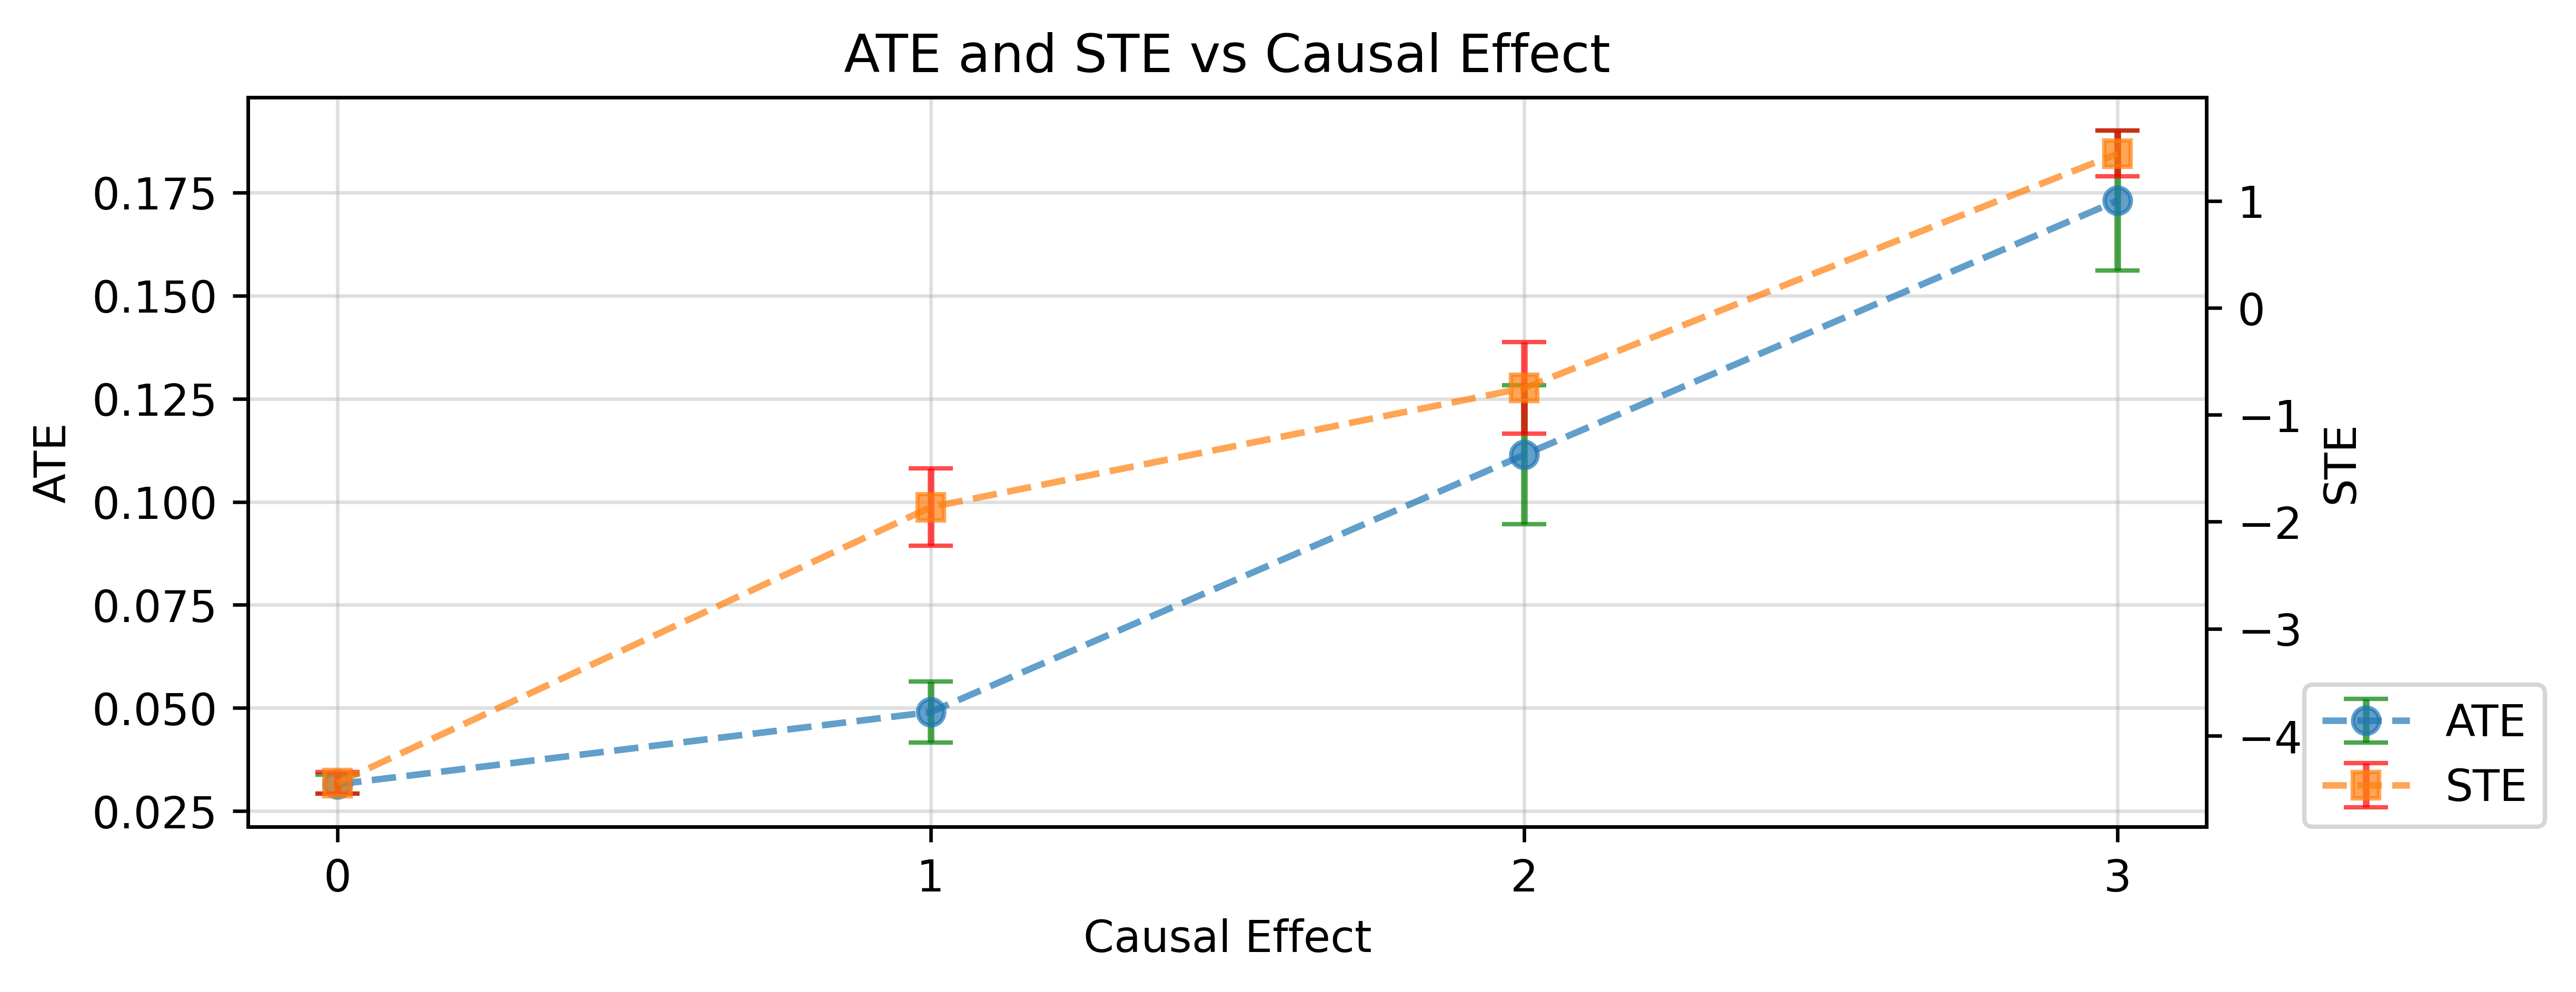

In [32]:
z = norm.ppf(0.95)

fig, ax1 = plt.subplots(figsize=(8, 3), dpi=600)
ax2 = ax1.twinx()

colors = {
    "ATE": "tab:blue",
    "STE": "tab:orange"
}

# ---- ATE (left y-axis) ----
temp_ate = raw_results.groupby('causal_effect')['ATE'].agg(['mean', 'std', 'count'])
ax1.errorbar(
    x=temp_ate.index,
    y=temp_ate['mean'],
    yerr=z * temp_ate['std'] / np.sqrt(temp_ate['count']),
    label='ATE',
    color=colors['ATE'],
    ecolor='green',
    capsize=5,
    elinewidth=1.5,
    marker='o',
    linestyle='--',
    alpha=0.7
)

# ---- STE (right y-axis) ----
temp_ste = raw_results.groupby('causal_effect')['STE'].agg(['mean', 'std', 'count'])
ax2.errorbar(
    x=temp_ste.index,
    y=temp_ste['mean'],
    yerr=z * temp_ste['std'] / np.sqrt(temp_ste['count']),
    label='STE',
    color=colors['STE'],
    ecolor='red',
    capsize=5,
    elinewidth=1.5,
    marker='s',
    linestyle='--',
    alpha=0.7
)

# Labels & styling
ax1.set_xlabel('Causal Effect')
ax1.set_ylabel('ATE')
ax2.set_ylabel('STE')

ax1.set_xticks(range(4))
ax1.grid(alpha=0.4)

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc=(1.05, 0))

plt.title('ATE and STE vs Causal Effect')

plt.savefig(
    figures_path / 'ate_ste_vs_causal_effect.jpeg',
    bbox_inches='tight'
)
plt.show()

In [33]:
cmap = plt.get_cmap("tab10")
color_map = {}
for i, col in enumerate(baselines):
    base_color = cmap(i % 10)
    if i < 10:
        color_map[col] = base_color
    else:
        c = mcolors.to_rgb(base_color)
        color_map[col] = tuple(min(1, x * 1.4) for x in c)

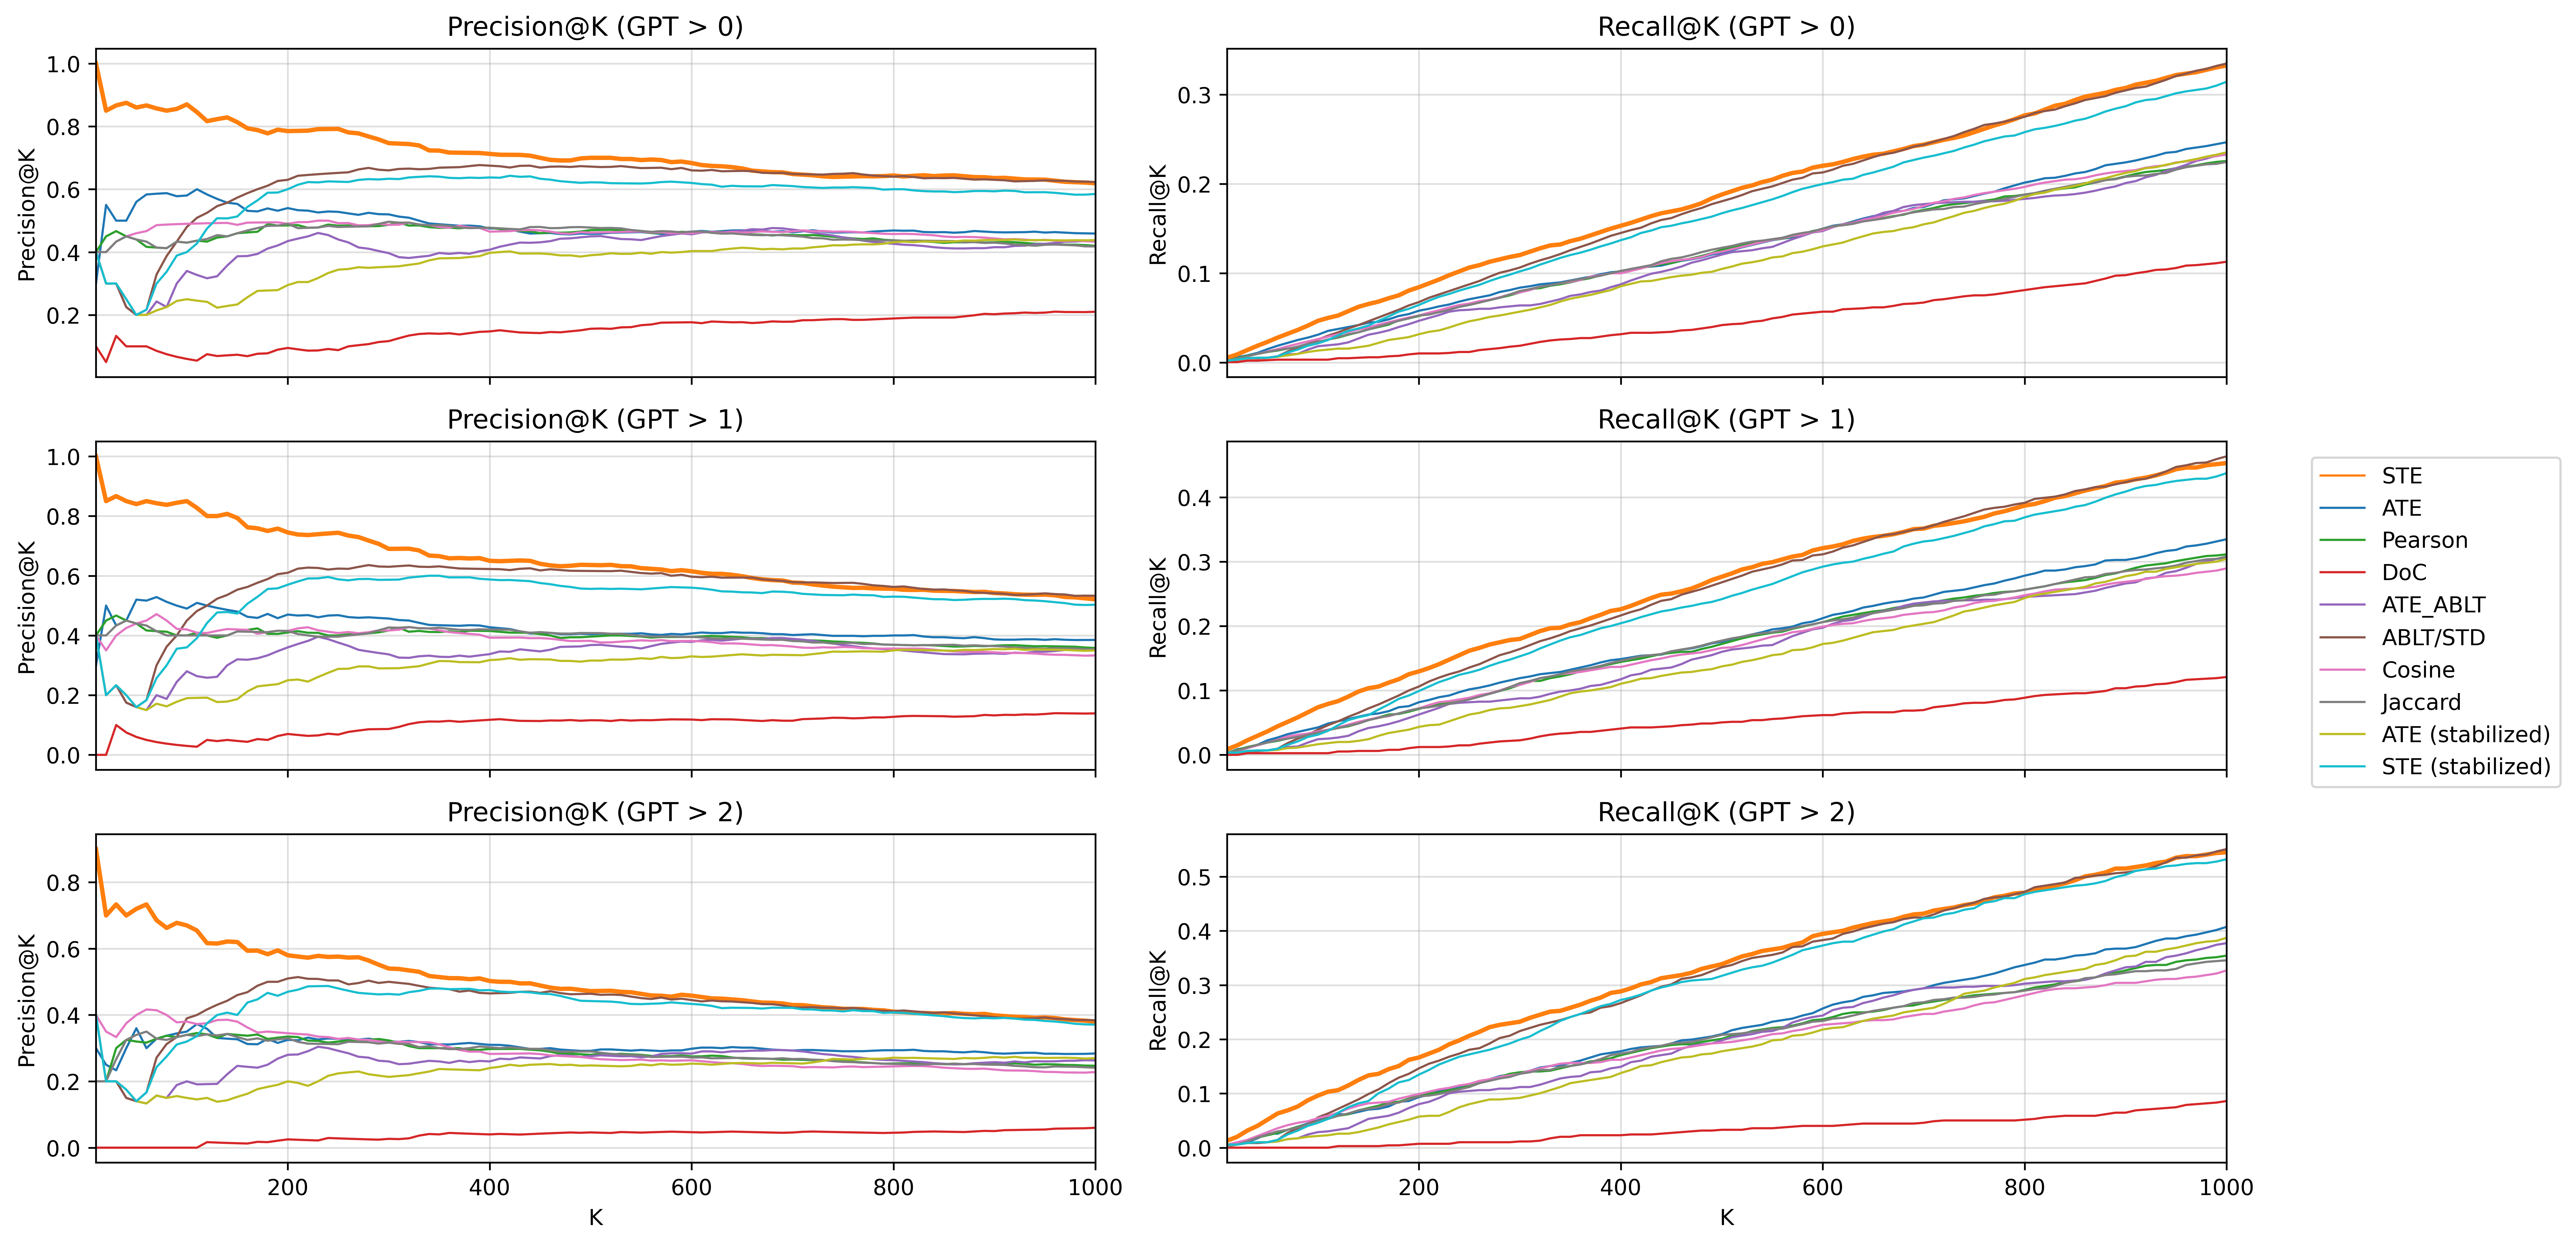

In [34]:
if DATASET == 'steam':
    Ks = np.arange(10, 1001, step=10)
elif DATASET == 'goodreads':
    Ks = np.arange(10, 7001, step=10)
elif DATASET == 'ml-10m':   
    Ks = np.arange(10, 501, step=5)
elif DATASET == 'ml-1m':   
    Ks = np.arange(10, 1001, step=5)

fig, axes = plt.subplots(
    3, 2,
    figsize=(14.5, 8),
    dpi=600,
    sharex=True
)

for GPT in range(3):
    # Ground truth
    y_true = raw_results['causal_effect'] > GPT
    total_positives = y_true.sum()

    # Store curves + mean scores
    precision_curves = {}
    recall_curves = {}
    mean_precision = {}
    mean_recall = {}

    # ---- compute curves ----
    for col in baselines:
        col_ser = raw_results.sort_values(by=col, ascending=False)['causal_effect']
        causal_link = col_ser > GPT

        precision_vals = np.array([
            causal_link[:K].sum() / K
            for K in Ks
        ])

        recall_vals = np.array([
            causal_link[:K].sum() / total_positives
            for K in Ks
        ])

        precision_curves[col] = precision_vals
        recall_curves[col] = recall_vals

        mean_precision[col] = precision_vals.mean()
        mean_recall[col] = recall_vals.mean()

    # ---- select best baselines (by mean) ----
    best_precision_col = max(mean_precision, key=mean_precision.get)
    best_recall_col = max(mean_recall, key=mean_recall.get)

    # ---- plot Precision@K ----
    for col in baselines:
        axes[GPT, 0].plot(
            Ks,
            precision_curves[col],
            color=color_map[col],
            linewidth=2 if col == best_precision_col else 1,
            label=col
        )

    # ---- plot Recall@K ----
    for col in baselines:
        axes[GPT, 1].plot(
            Ks,
            recall_curves[col],
            color=color_map[col],
            linewidth=2 if col == best_recall_col else 1,
            label=col
        )

    # ---- formatting ----
    axes[GPT, 0].set_title(f"Precision@K (GPT > {GPT})")
    axes[GPT, 1].set_title(f"Recall@K (GPT > {GPT})")

    axes[GPT, 0].set_ylabel("Precision@K")
    axes[GPT, 1].set_ylabel("Recall@K")

    for j in range(2):
        axes[GPT, j].grid(alpha=0.4)
        axes[GPT, j].set_xlim([Ks[0], Ks[-1]])

# ---- x labels only on bottom row ----
axes[-1, 0].set_xlabel("K")
axes[-1, 1].set_xlabel("K")

# ---- shared legend ----
# swap indices 0 and 1
order = list(range(len(baselines)))
order[0], order[1] = order[1], order[0]

legend_handles = [
    Line2D(
        [0], [0],
        color=axes[0, 0].lines[i].get_color(),
        lw=1,
        label=baselines[i]
    )
    for i in order
]

fig.legend(
    handles=legend_handles,
    labels=[baselines[i] for i in order],
    bbox_to_anchor=(1.01, 0.5),
    loc="center left"
)

plt.tight_layout()
plt.savefig(
    figures_path / 'precision_recall_at_k.jpeg',
    bbox_inches='tight'
)
plt.show()

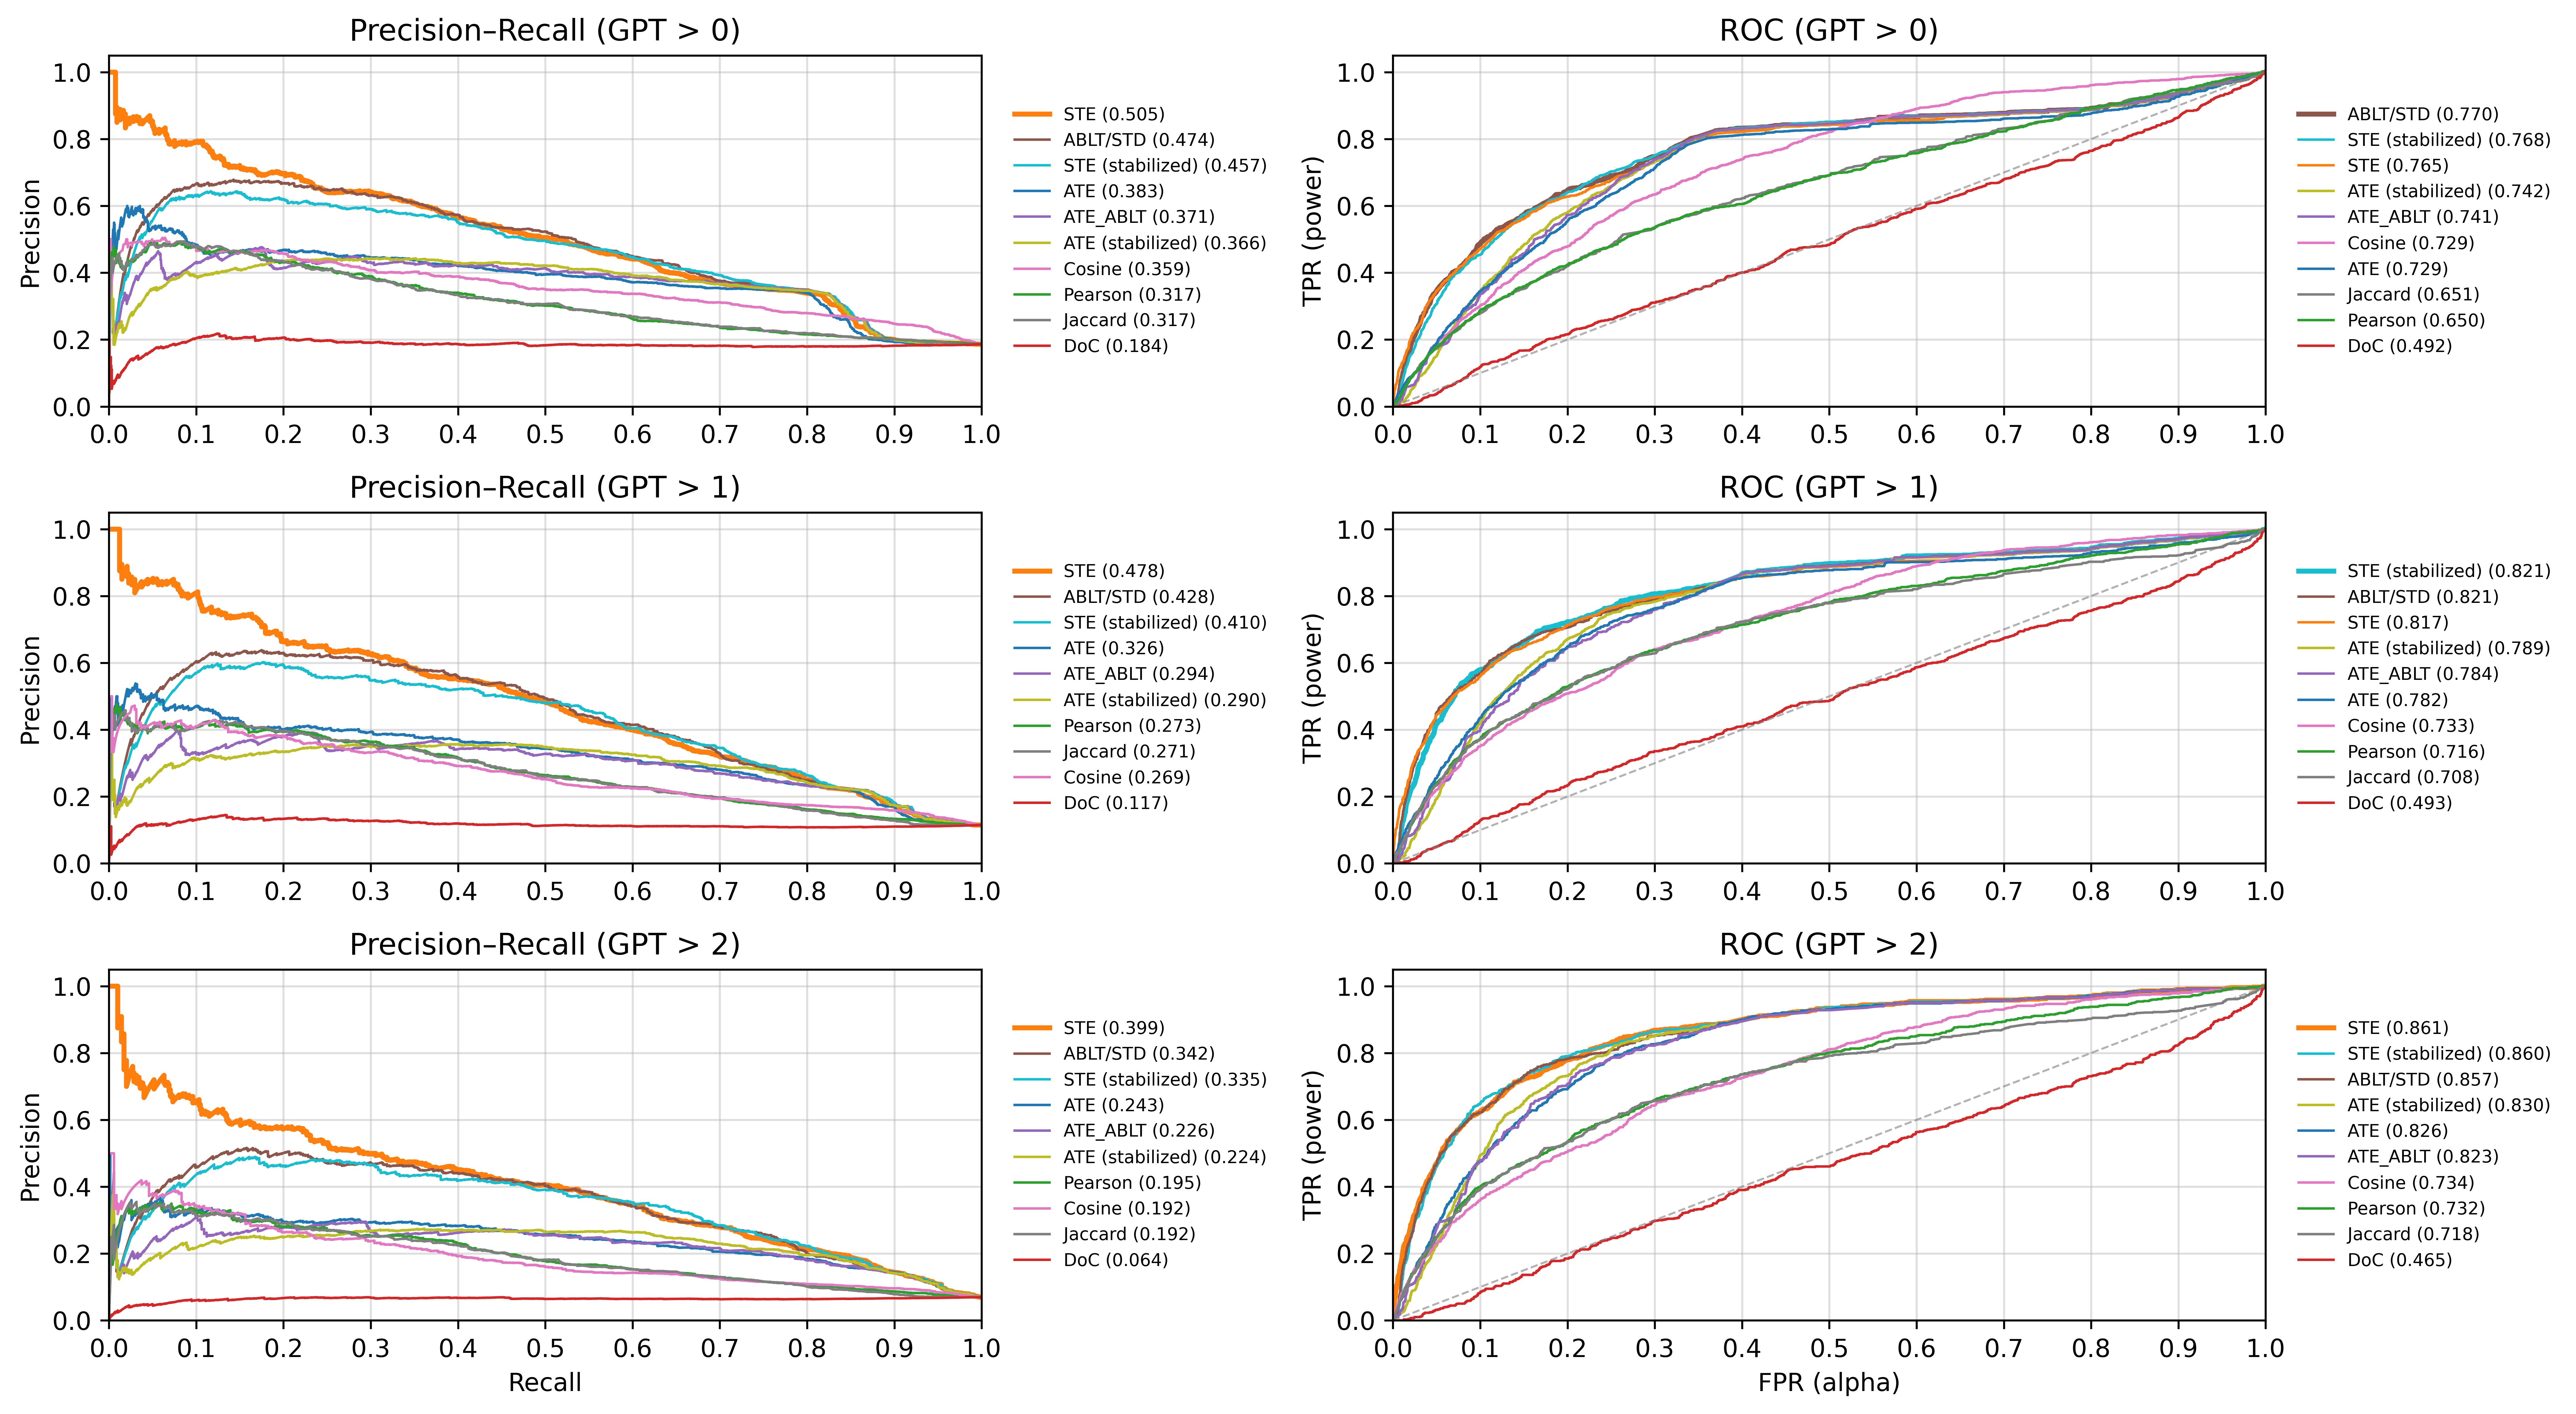

Average Precision                 ROC-AUC                
                             GPT>0   GPT>1   GPT>2   GPT>0   GPT>1   GPT>2
ATE                         38.35%  32.60%  24.35%  72.94%  78.18%  82.56%
STE                         50.53%  47.76%  39.90%  76.51%  81.74%  86.08%
Pearson                     31.74%  27.34%  19.50%  65.01%  71.60%  73.21%
DoC                         18.44%  11.68%   6.39%  49.22%  49.30%  46.47%
ATE_ABLT                    37.08%  29.39%  22.64%  74.12%  78.39%  82.34%
ABLT/STD                    47.42%  42.85%  34.20%  77.03%  82.05%  85.75%
Cosine                      35.94%  26.93%  19.21%  72.94%  73.30%  73.38%
Jaccard                     31.70%  27.13%  19.21%  65.13%  70.83%  71.85%
ATE (stabilized)            36.59%  29.04%  22.42%  74.16%  78.87%  83.04%
STE (stabilized)            45.69%  41.04%  33.52%  76.82%  82.12%  86.04%

In [35]:
summary = {col: {} for col in baselines}

fig, axes = plt.subplots(3, 2, figsize=(14.5, 8), dpi=600)

for GPT in range(3):
    y_true = (raw_results['causal_effect'] > GPT).astype(int).values

    # --- collect curves + scores first ---
    pr_data = []
    roc_data = []

    for col in baselines:
        y_score = raw_results[col].values

        # Precision–Recall
        precision, recall, _ = precision_recall_curve(y_true, y_score)
        ap = average_precision_score(y_true, y_score)
        summary[col][('Average Precision', f'GPT>{GPT}')] = ap
        pr_data.append((col, recall[:-1], precision[:-1], ap))

        # ROC
        fpr, tpr, _ = roc_curve(y_true, y_score)
        auc = roc_auc_score(y_true, y_score)
        summary[col][('ROC-AUC', f'GPT>{GPT}')] = auc
        roc_data.append((col, fpr, tpr, auc))

    # --- sort by score ---
    pr_data.sort(key=lambda x: x[3], reverse=True)   # by AP
    roc_data.sort(key=lambda x: x[3], reverse=True)  # by AUC

    # --- plot PR ---
    for rank, (col, recall, precision, ap) in enumerate(pr_data):
        axes[GPT, 0].plot(
            recall,
            precision,
            lw=2 if rank == 0 else 1,
            color=color_map[col],
            label=f"{col} ({ap:.3f})"
        )

    # --- plot ROC ---
    for rank, (col, fpr, tpr, auc) in enumerate(roc_data):
        axes[GPT, 1].plot(
            fpr,
            tpr,
            lw=2 if rank == 0 else 1,
            color=color_map[col],
            label=f"{col} ({auc:.3f})"
        )
    axes[GPT, 1].plot([0, 1], [0, 1], ls="--", lw=0.8, color="grey", alpha=0.6)
    

    # ---- Titles & formatting ----
    axes[GPT, 0].set_title(f"Precision–Recall (GPT > {GPT})")
    axes[GPT, 1].set_title(f"ROC (GPT > {GPT})")

    axes[GPT, 0].set_ylabel("Precision")
    axes[GPT, 1].set_ylabel("TPR (power)")

    for j in range(2):
        axes[GPT, j].set_xlim([0, 1])
        axes[GPT, j].set_ylim([0, None])
        axes[GPT, j].set_xticks(np.arange(0, 1.1, 0.1))
        axes[GPT, j].grid(alpha=0.4)
        if auxiliary:
            axes[GPT, j].legend(
                fontsize=7,
                loc='center left',
                bbox_to_anchor=(1.02, 0.5),
                frameon=False
            )
        else:
            axes[GPT, j].legend(
                fontsize=7,
                loc='upper right' if j == 0 else 'lower right',
                frameon=False
            )

# Bottom x-labels only
axes[-1, 0].set_xlabel("Recall")
axes[-1, 1].set_xlabel("FPR (alpha)")

plt.tight_layout()
plt.savefig(
    figures_path / 'pr_roc_curves.jpeg', 
    bbox_inches='tight'
)
plt.show()

summary_df = pd.DataFrame(summary).T
columns_ordered = summary_df.columns[[0, 2, 4, 1, 3, 5]]
summary_df = summary_df[columns_ordered]
summary_df = summary_df.map(lambda x: f"{x:.2%}")
display(summary_df)

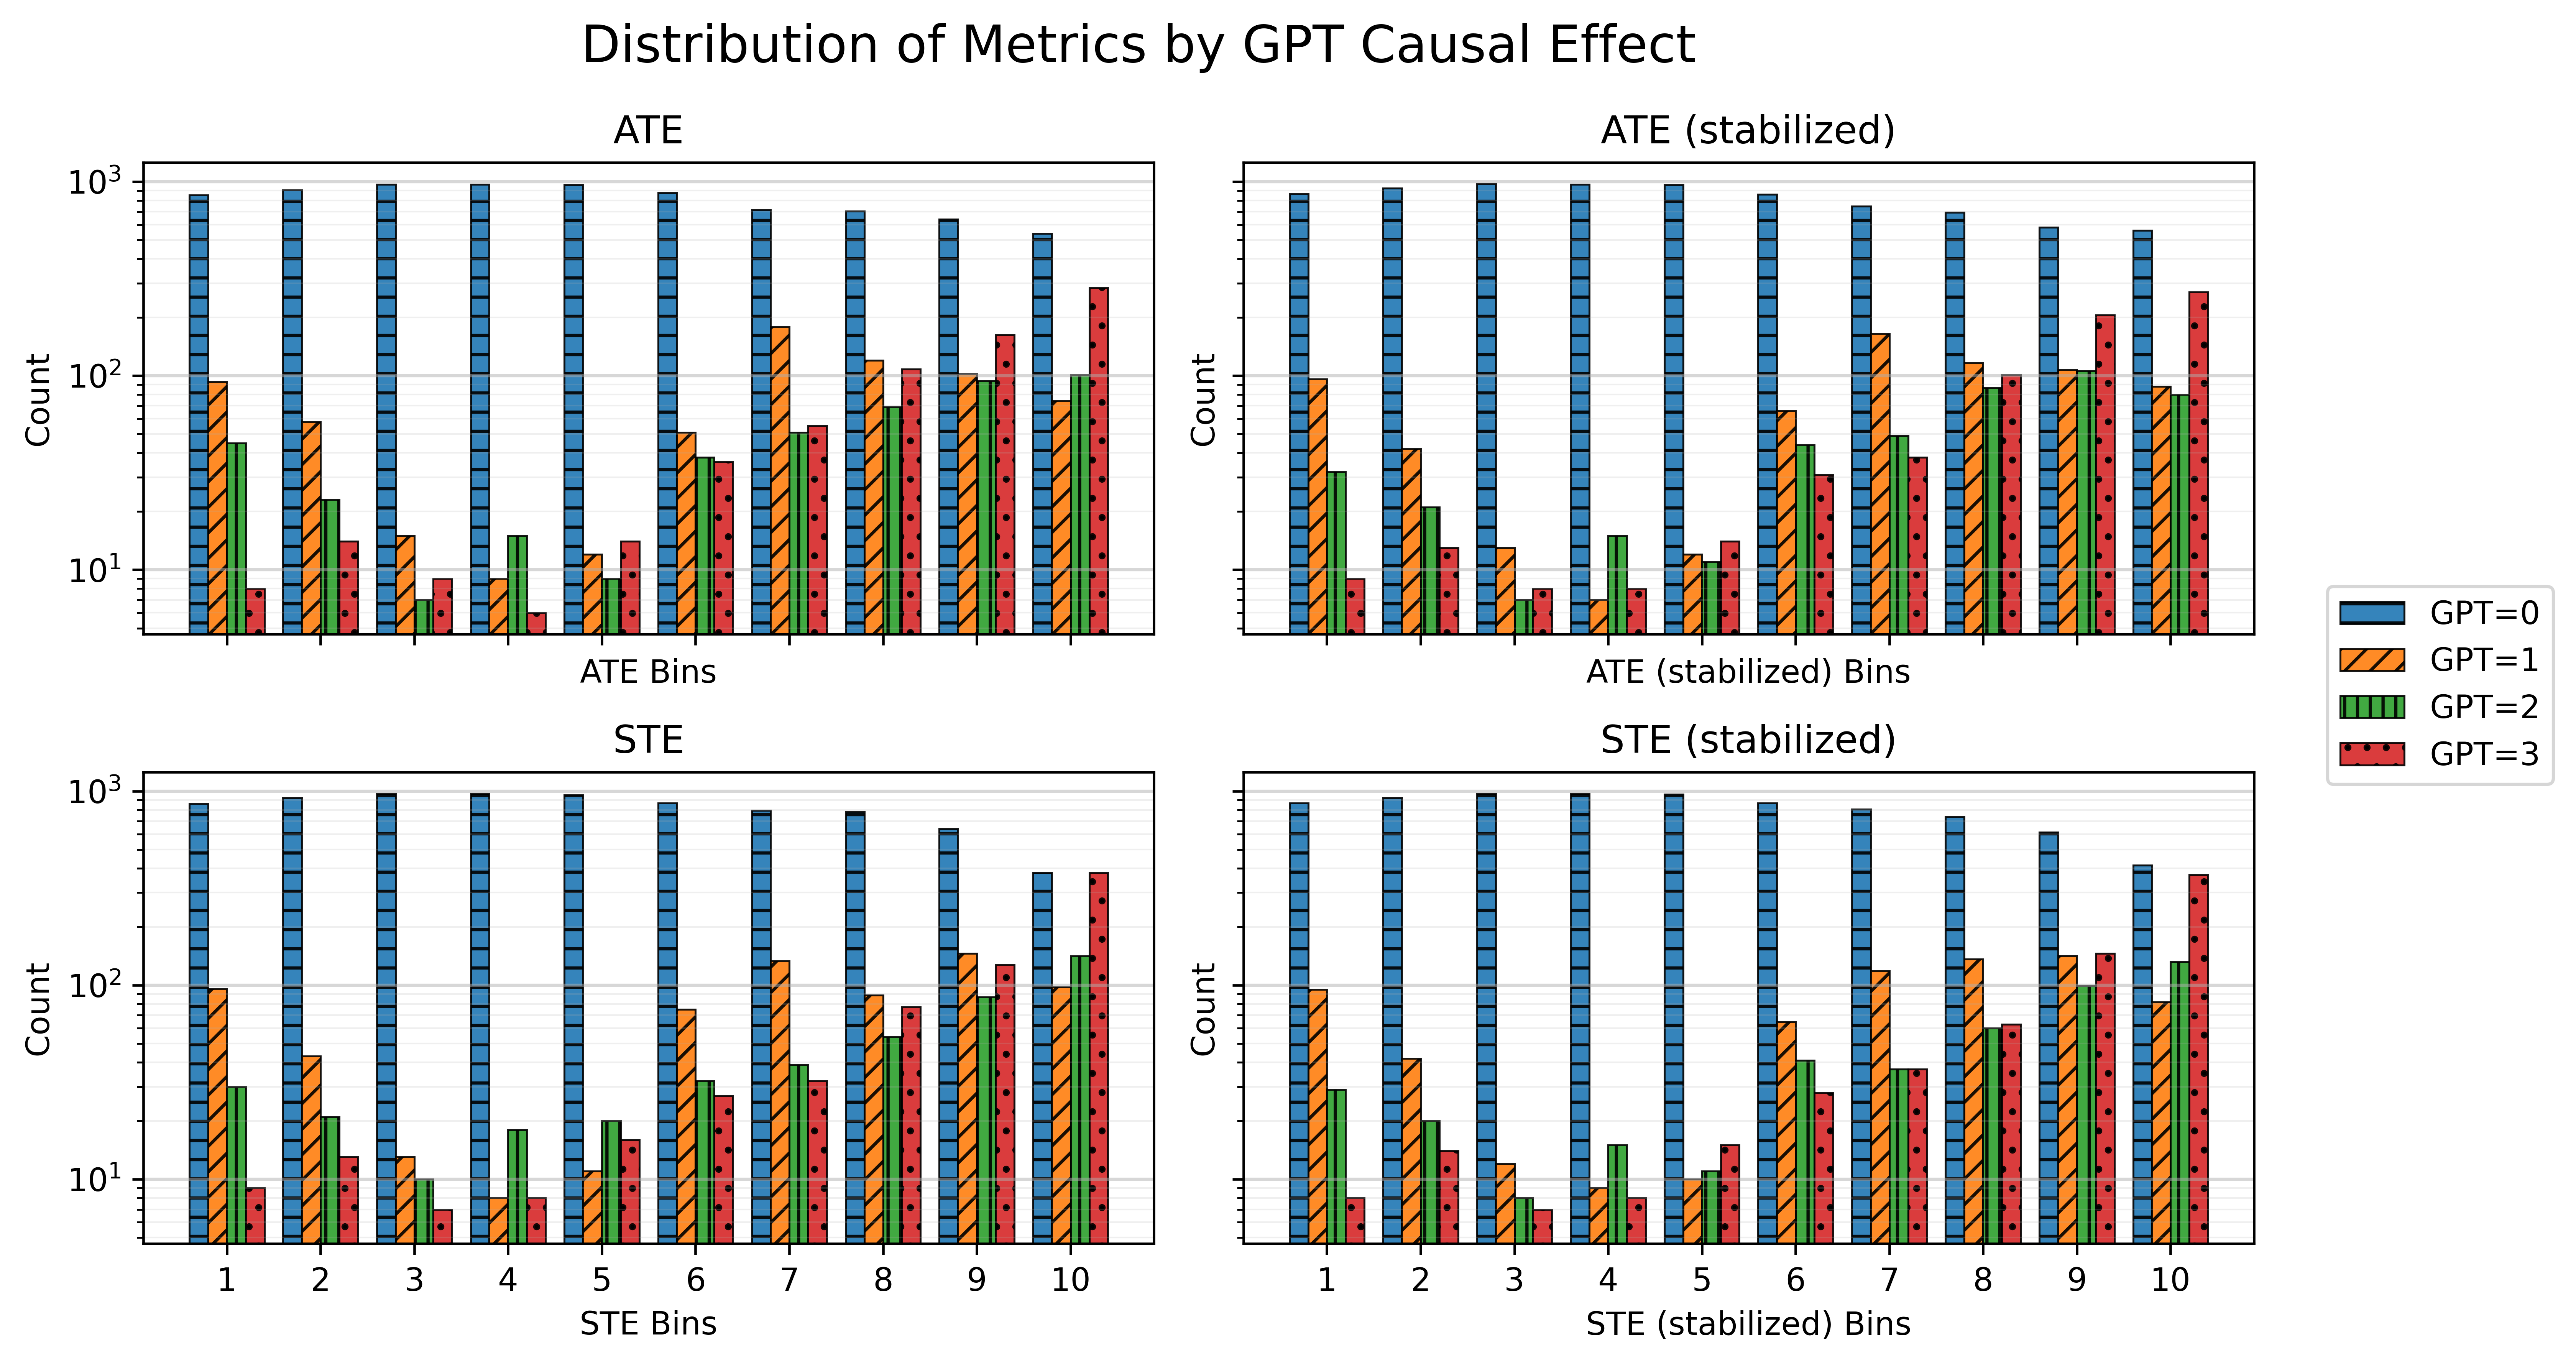

In [36]:
num_bins = 10
w = 0.2

fig, axes = plt.subplots(2, 2, figsize=(10, 6), sharex=True, sharey=True, dpi=600)

hatches = ['--', '///', '|||', '..']   # one per GPT
colors  = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']

for ax, metric in zip(axes.flatten(), ["ATE", "ATE (stabilized)", "STE", "STE (stabilized)"]):

    # Quantile bins for the current metric
    bins = np.quantile(
        raw_results[metric].values,
        np.arange(0, 1, 1 / num_bins)
    )

    df = raw_results[[metric, 'causal_effect']].copy()
    df['metric_bin'] = np.digitize(df[metric], bins) - 1

    for GPT in range(4):
        subset = df[df['causal_effect'] == GPT]
        counts = subset['metric_bin'].value_counts().sort_index()

        ax.bar(
            counts.index + (GPT - 1.5) * w,
            counts.values,
            width=w,
            alpha=0.9,
            color=colors[GPT],
            hatch=hatches[GPT],
            edgecolor='black', 
            linewidth=0.6,
            label=f'GPT={GPT}'
        )

    ax.set_xticks(range(num_bins))
    ax.set_xticklabels(range(1, num_bins + 1))
    ax.set_xlabel(f'{metric} Bins')
    ax.set_ylabel('Count')
    ax.set_title(f'{metric}')

    ax.set_yscale('log')
    ax.grid(axis='y', which='major', alpha=0.5, linewidth=1)
    ax.grid(axis='y', which='minor', alpha=0.2, linewidth=0.5)

fig.suptitle('Distribution of Metrics by GPT Causal Effect', fontsize=16)

# Get legend entries from one subplot
handles, labels = axes.flatten()[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc='center left',
    bbox_to_anchor=(1.01, 0.5)
)

# Leave space on the right for the legend
plt.tight_layout()

plt.savefig(
    figures_path / 'metric_distribution_by_causal_effect.jpeg',
    bbox_inches='tight'
)
plt.show()

# 3 ESS Analysis

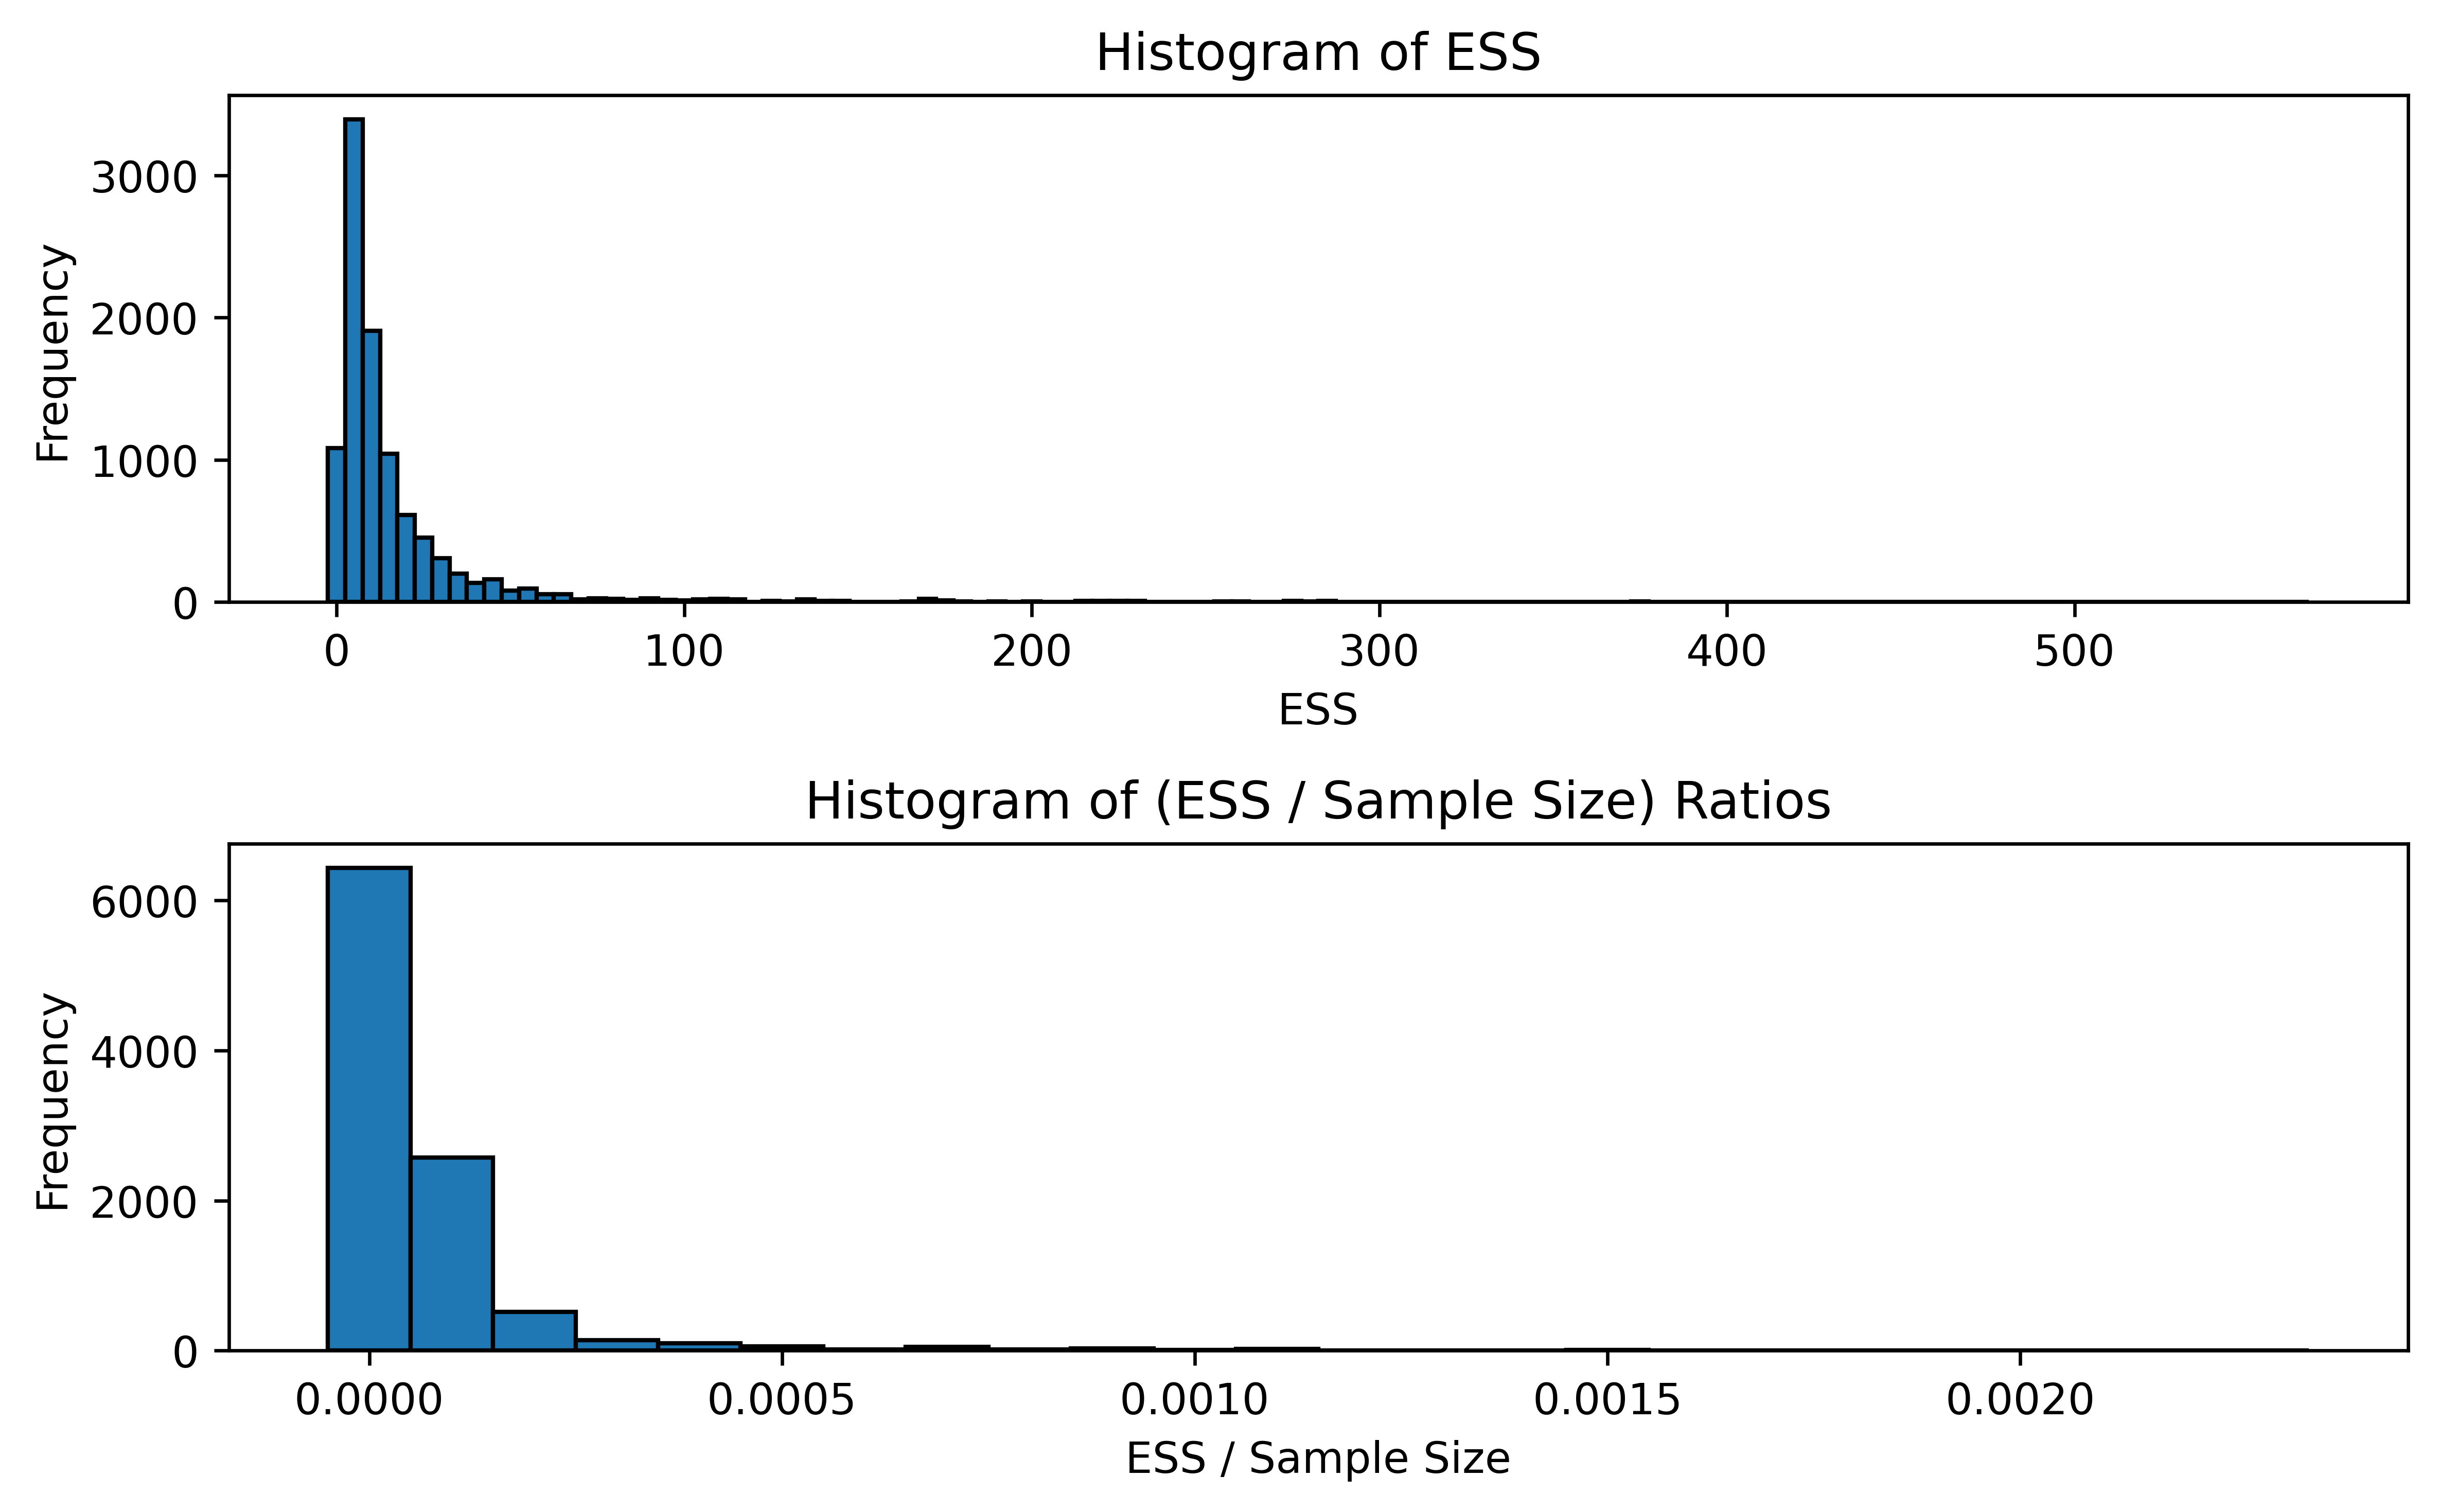

In [37]:
ratios = raw_results['ESS_ATE'] / raw_results['size']

figs, axes = plt.subplots(2, 1, figsize=(8, 5), dpi=600)

step = 5
bins = np.arange(-0.5*step, raw_results['ESS_ATE'].max()+1.5*step, step)
axes[0].hist(raw_results['ESS_ATE'], bins=bins, edgecolor='k')
axes[0].set_xlabel('ESS')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Histogram of ESS')

step = 1e-4
bins = np.arange(-0.5*step, ratios.max()+1.5*step, step)
axes[1].hist(ratios, bins=bins, edgecolor='k')
axes[1].set_xlabel('ESS / Sample Size')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Histogram of (ESS / Sample Size) Ratios')

plt.tight_layout()
plt.show()

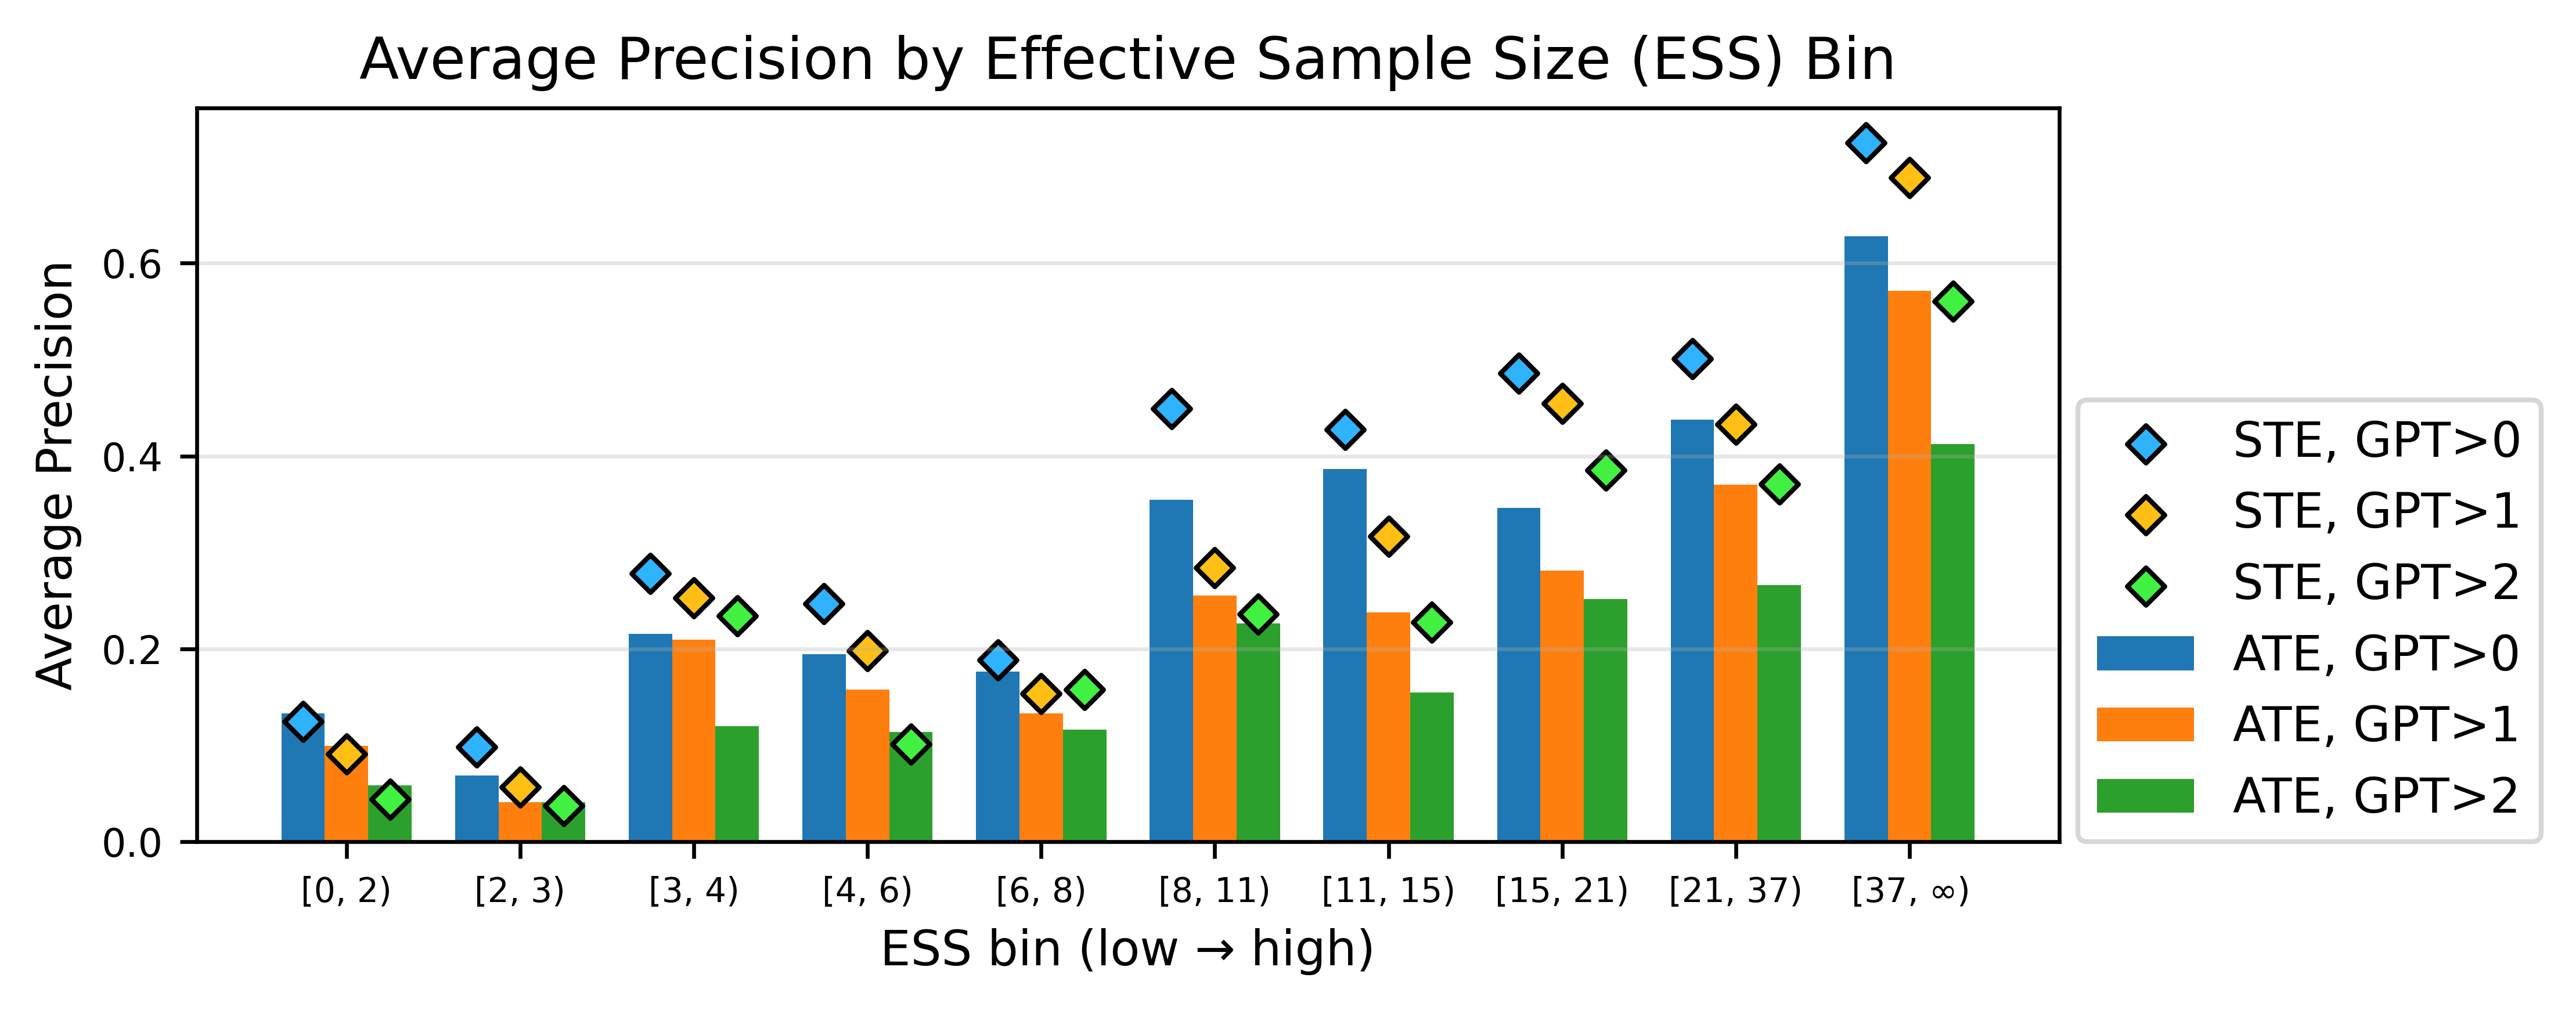

In [38]:
df = raw_results[['ESS_ATE', 'size', 'causal_effect', 'STE', 'ATE']].dropna().copy()
bins = np.quantile(df['ESS_ATE'].values, np.arange(0, 1, 1 / num_bins))
df['ess_bin'] = np.digitize(df['ESS_ATE'].values, bins) - 1

gpt_thresholds = [0, 1, 2]
score_cols = ['ATE', 'STE']
colors = ['tab:blue', 'tab:orange', 'tab:green']

results = {
    s: {gpt: [] for gpt in gpt_thresholds} 
    for s in score_cols
}
bin_labels = []

for b in range(num_bins):
    sub = df[df['ess_bin'] == b].copy()
    # bin_labels.append(f'Bin {b+1}')
    if b == 0:
        bin_labels.append(f'[0, {int(bins[b+1])})')
    elif b < num_bins - 1:
        bin_labels.append(f'[{int(bins[b])}, {int(bins[b+1])})')
    else:
        bin_labels.append(f'[{int(bins[b])}, $\infty$)')
    
    for score_col in score_cols:
        y_score = sub[score_col].values
        
        for gpt in gpt_thresholds:
            y_true = (sub['causal_effect'].values > gpt).astype(int)
            ap = average_precision_score(y_true, y_score)
            results[score_col][gpt].append(ap)

x = np.arange(num_bins)
width = 0.25

plt.figure(figsize=(7.5, 3), dpi=600)

for gpt in gpt_thresholds:
    color = cmap(gpt)
    x_loc = x + (gpt - 1) * width
    plt.bar(
        x_loc, 
        results['ATE'][gpt], 
        width,
        color = color,
        label=f'ATE, GPT>{gpt}'
    )
    plt.scatter(
        x_loc, 
        results['STE'][gpt], 
        color=tuple(min(1, x * 1.5) for x in color),
        marker='D', 
        s=30,
        edgecolor='black',
        linewidth=1, 
        label=f'STE, GPT>{gpt}' 
    )

plt.xlabel('ESS bin (low → high)', fontsize=10)
plt.ylabel('Average Precision', fontsize=10)
plt.title(f'Average Precision by Effective Sample Size (ESS) Bin', fontsize=12)
plt.xticks(x, bin_labels, rotation=0, fontsize=7)
plt.yticks(fontsize=8)
plt.legend(
    loc=(1.01, 0.0), fontsize=10
)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(
     figures_path / 'ate_ste_performance_by_ess_bin.jpeg', 
    bbox_inches='tight'
)
plt.show()

In [39]:
# out_text = ""
# for bin in range(num_bins):
#     out_text += f"Bin {bin+1}:\n"
#     for gpt in gpt_thresholds:
#         ap_ate = results['ATE'][gpt][bin]
#         ap_ste = results['STE'][gpt][bin]
#         out_text += f"  GPT>{gpt}: ATE AP={ap_ate:.4f}, STE AP={ap_ste:.4f}\n"
#     out_text += "\n"

# here = Path.cwd()
# text_path = Path.cwd() / 'ess_bin_performance.txt'
# text_path.write_text(out_text)

# 4 Further Analysis

In [40]:
summary_dict = {}
for ds in datasets:
    folder = base_artifacts / 'API_Results' / ds
    csvs_in_folder = [p.name for p in folder.iterdir() if p.is_file() and p.suffix == '.csv']
    oracle_file_name = csvs_in_folder[0]
    oracle = pd.read_csv(folder / oracle_file_name)
    summary_dict[ds] = oracle['causal_effect'].value_counts().to_dict()

summary_df = (
    pd.DataFrame(summary_dict)
    .T
    .rename_axis('Dataset', axis=0)
    .rename_axis('Causal Effect', axis=1)
)
summary_df

Causal Effect,0,1,2,3
Dataset,,,,
ml-1m,9862,84,34,20
steam,9582,286,95,37
goodreads,9187,520,115,178
ml-10m,8885,672,209,234


In [47]:
summary_dict = {}
for ds in datasets:
    path = base_artifacts / 'Datasets' / 'Processed' / ds / 'data_clean.csv'
    data = pd.read_csv(path)
    n_users = data['user_id'].nunique()
    n_items = data['item_id'].nunique()
    n_total = len(data)
    pos = n_total / (n_users * n_items)
    summary_dict[ds] = {
        'n_users': n_users,
        'n_items': n_items,
        'n_total': n_total,
        'pos': pos
    }

summary_df = (
    pd.DataFrame(summary_dict)
    .T
    .rename_axis('Dataset', axis=0)
)
summary_df

,n_users,n_items,n_total,pos
Dataset,,,,
ml-1m,6040.0,3706.0,1000209.0,0.044684
steam,8364.0,12434.0,1360027.0,0.013077
goodreads,7801.0,6384.0,869451.0,0.017458
ml-10m,5369.0,3362.0,3392139.0,0.187924
